<h1 align="center"><b>Deep Learning for Astronomical Object Classification</b></h1>



# DATASET

https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17

La dataset contient :

100 000 observations astronomiques,
17 features astrophysiques,
3 classes :
STAR,
GALAXY,
QSO (quasar).

La dataset est tabulaire, propre, structuré, numérique,
idéal sklearn pipelines.

Pipeline :
1. Data Exploration
classes,
distributions,
corrélations.
2. Data Cleaning
NaN,
outliers,
scaling.
3. Preprocessing Pipeline
StandardScaler,
PCA,
Pipeline sklearn.
4. Baseline
LogisticRegression.
5. Modèles avancés
RandomForest,
XGBoost.
6. Deep Learning
Dense Neural Network.
7. Evaluation
accuracy,
precision,
recall,
confusion matrix,
ROC AUC.

L'bjectif :

Classifier automatiquement
les objets célestes.

Les features importantes

u	         ->         ultraviolet

g	         ->         bande verte

r	         ->         bande rouge

i	         ->         proche infrarouge

z	         ->         infrarouge

redshift	 ->      décalage spectral

alpha	     ->      ascension droite

delta	     ->      déclinaison

Plan du projet :

Partie 1 — EDA
distributions classes,
corrélations,
PCA 2D,
visualisation redshift.

Partie 2 — ML classique
Logistic Regression,
RandomForest,
XGBoost,
SVM.

Partie 3 — Deep Learning
Dense Neural Network TensorFlow/Keras.

Partie 4 — Comparaison scientifique

Comparer :
accuracy,
precision,
recall,
F1,
temps d’entraînement,
interprétabilité.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

# os.chdir allows you to change directories, like cd in the Terminal
os.chdir('/content/drive/MyDrive/Projet Data Science')

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/Projet Data Science/star_classification.csv")

In [5]:
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

Nombre de lignes : 100000
Nombre de colonnes : 18


In [7]:
display(df.head())

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [8]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

None

In [9]:
display(df.dtypes)

,0
obj_ID,float64
alpha,float64
delta,float64
u,float64
g,float64
r,float64
i,float64
z,float64
run_ID,int64
rerun_ID,int64


In [10]:
for col in df.columns:
    print(col)

obj_ID
alpha
delta
u
g
r
i
z
run_ID
rerun_ID
cam_col
field_ID
spec_obj_ID
class
redshift
plate
MJD
fiber_ID


In [14]:
display(df.describe())

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


In [15]:
display(
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

,0
obj_ID,0
alpha,0
delta,0
u,0
g,0
r,0
i,0
z,0
run_ID,0
rerun_ID,0


In [16]:
print(df.duplicated().sum())

0


In [12]:
df["class"].value_counts()

,count
class,
GALAXY,59445
STAR,21594
QSO,18961


In [13]:
display(df["class"].value_counts(normalize=True) * 100)

,proportion
class,
GALAXY,59.445
STAR,21.594
QSO,18.961


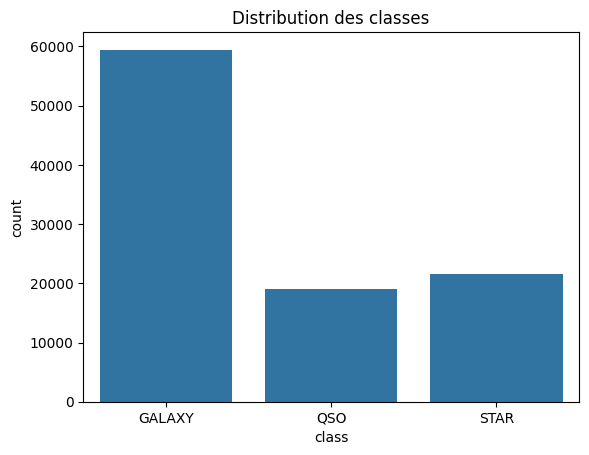

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="class")

plt.title("Distribution des classes")
plt.show()

Pourcentage approximatif :

GALAXY	~59 %

STAR	~21 %

QSO	~18 %

On voit que les trois classes existent en quantité importante, aucune classe n’est ultra rare et les modèles pourront apprendre correctement.

La pipeline pourra contenir :

EDA

preprocessing

feature engineering

pipelines sklearn

PCA

clustering

RandomForest

XGBoost

Dense Neural Network

GridSearchCV


# RECHERCHES SCIENTIFIQUES SUR LE SUJET

CLASSIFICATION OF QUASARS, GALAXIES,
AND STARS USING MULTI-MODAL DEEP
LEARNING

https://arxiv.org/pdf/2205.10745

Cette recherche essaie de résoudre un problème très concret en astronomie :

Quand on regarde le ciel avec un télescope,
comment reconnaître automatiquement :
- une étoile,
- une galaxie,
- ou un quasar ?

Le papier propose une solution moderne :

utiliser du Deep Learning multimodal.

C’est-à-dire :

combiner plusieurs types de données
dans une seule IA.

Star-galaxy Classification Using Deep Convolutional Neural
Networks

https://arxiv.org/pdf/1608.04369

Cette recherche cherche à résoudre un problème astronomique fondamental :

Quand on observe le ciel,
comment savoir automatiquement
si un objet est une étoile
ou une galaxie ?

Le papier propose d’utiliser :

des réseaux de neurones convolutifs (CNN / ConvNet)

pour classifier directement les images astronomiques.



Stellar Classification with Vision Transformer and SDSS
Photometric Images

https://www.mdpi.com/2218-1997/10/5/214

Cette recherche est très intéressante parce qu’elle répond à un vrai problème astronomique moderne :

Il y a énormément d’étoiles observées,
mais très peu ont été analysées
manuellement par des astronomes.

Le but du papier est donc :

utiliser l’IA pour classifier automatiquement
les types d’étoiles
à partir de simples images astronomiques.

Plusieurs modèles sont comparés dans cette recherche :
VGG19,
ResNet34,
DenseNet169,
EfficientNet,
SCNet,
leur modèle Stellar-ViT.

Ils utilisent ici seulement des images,
pas les spectres complets. Cela permet de classifier
des millions d’étoiles automatiquement.

La dataset :

SDSS17 Stellar Classification Dataset

contient :

les labels :

STAR,

GALAXY,

QSO,

ET les coordonnées astronomiques :

alpha

delta

ET un identifiant :

obj_ID

Les colonnes :

alpha

delta

sont :

les coordonnées de l’objet dans le ciel.

En astronomie :

alpha = Right Ascension (RA),

delta = Declination (DEC).

Le SDSS permet :

de récupérer une image

à partir de RA + DEC.

# NOUVELLE DATASET POUR LES IMAGES

https://www.sdss4.org/dr17/imaging/jpg-images-on-skyserver

Pour télécharger les images, on va utiliser directement l’API “JPEG Cutout”

du SDSS.

Avec cette API, on lui donne :

une coordonnée du ciel :

ra

dec

une taille,

un zoom,

et elle te renvoie :

une image astronomique JPEG.

Exemple :      

https://skyserver.sdss.org/dr19/VisualTools/navi/

On voit une vraie image SDSS avec :     

https://skyserver.sdss.org/dr17/SkyServerWS/ImgCutout/getjpeg?ra=180&dec=0&scale=0.2&width=256&height=256


Structure de l’URL :

https://skyserver.sdss.org/dr17/SkyServerWS/ImgCutout/getjpeg?

Paramètre	      ->   Rôle

ra	            ->   Right Ascension

dec	            ->   Declination

scale	          ->   zoom

width	          ->   largeur

height	        ->   hauteur

Dans la dataset Kaggle

On a déjà :

alpha

delta

qui correspondent :

à RA et DEC.

Donc :

On peut générer les URLs automatiquement.

In [18]:
df_small = df.sample(10, random_state=42)

In [19]:
import requests
import os

os.makedirs("images", exist_ok=True)

for idx, row in df_small.iterrows():

    ra = row["alpha"]
    dec = row["delta"]

    url = (
        f"https://skyserver.sdss.org/dr17/SkyServerWS/"
        f"ImgCutout/getjpeg?"
        f"ra={ra}&dec={dec}"
        f"&scale=0.2"
        f"&width=128"
        f"&height=128"
    )

    response = requests.get(url)

    filename = f"images/{row['obj_ID']}.jpg"

    with open(filename, "wb") as f:
        f.write(response.content)

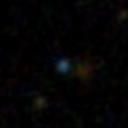

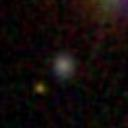

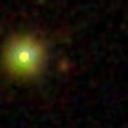

# CONCLUSION

Les données SDSS sont massives, et leur classification manuelle devient impossible.

Le Machine Learning permet d’automatiser l’identification des objets célestes.

C’est exactement le problème réel en astrophysique moderne.